# 4. Answering RQ4

**Can additional physiological data (monitoring the heart and skin) further improve accuracies of deep learning models for time series analysis in the predictions of task success and failure compared to the use of gaze (monitoring the eyes only)?**

---


In [ ]:
! pip install graphviz pydot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import cv2
import random
import pickle

from scipy.ndimage import gaussian_filter

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, Input, Concatenate, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import backend
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model

warnings.filterwarnings('ignore')
backend.clear_session()

In [ ]:
CECS_698_PATH = '/content/drive/MyDrive/CECS 698 - Data Analysis/'

EMBRACEPLUS_TRIMMED_PATH = os.path.join(CECS_698_PATH, 'EmbracePlus Trimmed')
EMBRACEPLUS_COMBINED_PATH = os.path.join(CECS_698_PATH, 'EmbracePlus Combined')

GAZEPOINT_TRIMMED_PATH = os.path.join(CECS_698_PATH, 'Gazepoint Trimmed')

PARTICIPANTS = [i for i in range(4, 27)]

GAZEPOINT_TUMBLING_WINDOW_DGM = os.path.join(CECS_698_PATH, 'Gazepoint Tumbling Window DGM')
GAZEPOINT_DGM_TIMESTAMP_LABELED = os.path.join(CECS_698_PATH, 'Gazepoint DGM Timestamp Labeled')
FPOG_SCANPATHS_PATH = os.path.join(CECS_698_PATH, 'FPOG Scanpaths')

MERGED_DATA = os.path.join(CECS_698_PATH, 'Merged Data')

GOOGLE_FORMS_SHEETS = os.path.join(CECS_698_PATH, 'Google Forms Sheets')

GROUP = {
    'E-H': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 24],
    'H-E': [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26]
}

# Particpants ids to exclude on specific assessments
EASY_ASSESSMENT_EXCLUDE = [11, 22]
HARD_ASSESSMENT_EXCLUDE = [15, 21]

# Size of image to store image files
IMG_SIZE=(70, 70)

# Gathering Data 📈
---

## Getting Scores

In [ ]:
df_scores = pd.read_csv(os.path.join(CECS_698_PATH, 'Participant Scores.csv'))
df_scores.head()

,Score,Participant ID,Assessment,Group,Elapsed Minutes,Successful/Unsuccessful,Python Experience,Year of Study
0,23,4,easy,E-H,10.933250,Successful,1 - 2 years,2nd Year Undergraduate
1,24,5,easy,E-H,7.933283,Successful,2 year or more,1st Year Graduate
2,26,6,easy,E-H,6.566667,Successful,1 - 2 years,3rd Year Undergraduate
3,25,7,easy,E-H,6.249933,Successful,1 - 2 years,3rd Year Undergraduate
4,20,8,easy,E-H,7.866567,Unsuccessful,1 - 2 years,3rd Year Undergraduate


{'Successful': 22, 'Unsuccessful': 20} (Proportion successful: 0.52, Proportion unsuccessful: 0.48)


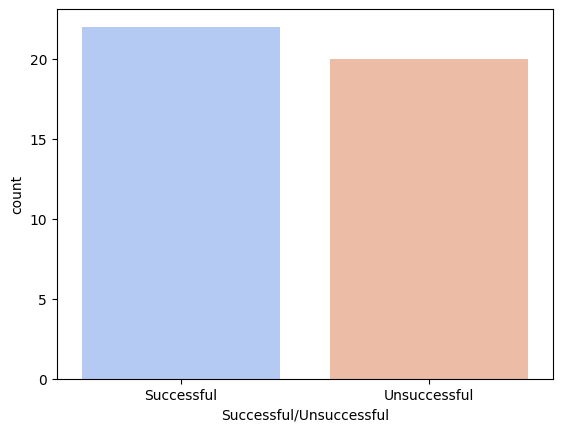

In [ ]:
sns.countplot(data=df_scores, x='Successful/Unsuccessful', palette='coolwarm')


label_counts = {'Successful': 0, 'Unsuccessful': 0}
for label in df_scores['Successful/Unsuccessful']:
    label_counts[label] += 1

print(f"{label_counts} (Proportion successful: {(label_counts['Successful'] / len(df_scores)):.2f}, Proportion unsuccessful: {(label_counts['Unsuccessful'] / len(df_scores)):.2f})")

## Combining Questionnaire Data

In [ ]:
# ----------------------------------------------- NASA TLX -----------------------------------------------
df_NASA_TLX = pd.read_csv(os.path.join(GOOGLE_FORMS_SHEETS, 'Participants Sheet - NASA TLX.csv'))#.drop('Dry Run?', axis=1)

df_NASA_TLX.columns = [
    'Timestamp',
    'Participant ID',
    'Mental Demand', # 1
    'Physical Demand', # 2
    'Temporal Demand', # 3
    'Performance', # 4
    'Effort', # 5
    'Frustration', # 6
    'Dry Run', # 7
]

df_NASA_TLX = df_NASA_TLX[df_NASA_TLX['Dry Run'].isnull()] # Take out dry run participants
df_NASA_TLX.drop(['Dry Run', 'Timestamp'], axis=1, inplace=True)


# ----------------------------------------------- Pre-Study KSS -----------------------------------------------
df_pre_study_KSS = pd.read_csv(os.path.join(GOOGLE_FORMS_SHEETS, 'Participants Sheet - Pre-Study KSS.csv'))
df_pre_study_KSS = df_pre_study_KSS[df_pre_study_KSS['Dry Run?'].isnull()]
df_pre_study_KSS.drop(['Dry Run?', 'Timestamp'], axis=1, inplace=True)
df_pre_study_KSS.columns = [
    'Participant ID',
    'Hours Awake',
    'Pre-Sleepiness Scale',
]
df_pre_study_KSS['Pre-Sleepiness Scale'] = df_pre_study_KSS['Pre-Sleepiness Scale'].apply(lambda x: int(x.split()[0]))


# ----------------------------------------------- Post-Study KSS -----------------------------------------------
df_post_study_KSS = pd.read_csv(os.path.join(GOOGLE_FORMS_SHEETS, 'Participants Sheet - Post-Study KSS.csv'))
df_post_study_KSS = df_post_study_KSS[df_post_study_KSS['Dry Run?'].isnull()]
df_post_study_KSS.drop(['Dry Run?', 'Timestamp'], axis=1, inplace=True)
df_post_study_KSS.columns = [
    'Participant ID',
    'Post-Sleepiness Scale',
]
df_post_study_KSS['Post-Sleepiness Scale'] = df_post_study_KSS['Post-Sleepiness Scale'].apply(lambda x: int(x.split()[0]))

df_all_questionnaires = df_NASA_TLX.merge(df_pre_study_KSS, on='Participant ID', how='inner').merge(df_post_study_KSS, on='Participant ID', how='inner')
df_all_questionnaires = df_all_questionnaires.merge(df_scores, left_on='Participant ID', right_on='Participant ID ').drop(columns=['Participant ID '])
df_all_questionnaires.head()

,Participant ID,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration,Hours Awake,Pre-Sleepiness Scale,Post-Sleepiness Scale,Score,Assessment,Group,Elapsed Minutes,Successful/Unsuccessful,Python Experience,Year of Study
0,4,6,7,1,7,5,3,7.0,8,2,23,easy,E-H,10.933250,Successful,1 - 2 years,2nd Year Undergraduate
1,4,6,7,1,7,5,3,7.0,8,2,24,hard,E-H,26.266650,Successful,1 - 2 years,2nd Year Undergraduate
2,5,6,1,2,4,5,6,3.0,7,7,24,easy,E-H,7.933283,Successful,2 year or more,1st Year Graduate
3,5,6,1,2,4,5,6,3.0,7,7,24,hard,E-H,26.933333,Successful,2 year or more,1st Year Graduate
4,6,3,5,2,6,4,2,7.0,5,7,26,easy,E-H,6.566667,Successful,1 - 2 years,3rd Year Undergraduate


In [ ]:
df_all_questionnaires.columns

Index(['Participant ID', 'Mental Demand', 'Physical Demand', 'Temporal Demand',
       'Performance', 'Effort', 'Frustration', 'Hours Awake',
       'Pre-Sleepiness Scale', 'Post-Sleepiness Scale', 'Score', 'Assessment',
       'Group', 'Elapsed Minutes', 'Successful/Unsuccessful',
       'Python Experience', 'Year of Study'],
      dtype='object')

## Get X, y data then `train_test_split`

In [ ]:
def read_y_labels(path):
    y = []
    for p in PARTICIPANTS:
        for diff in ['easy', 'hard']:
            if (diff == 'easy' and p in EASY_ASSESSMENT_EXCLUDE) or (diff == 'hard' and p in HARD_ASSESSMENT_EXCLUDE):
                continue # Excluded assessments (i.e ones with data loss)

            label = df_scores[(df_scores['Participant ID '] == p) & (df_scores['Assessment'] == diff)]['Successful/Unsuccessful'].values[0]
            label = 1 if label == 'Successful' else 0
            y.append(label)

    y = np.array(y)

    return y

def read_X_timeseries(path):
    X = []
    for p in PARTICIPANTS:
        for diff in ['easy', 'hard']:
            if (diff == 'easy' and p in EASY_ASSESSMENT_EXCLUDE) or (diff == 'hard' and p in HARD_ASSESSMENT_EXCLUDE):
                continue # Excluded assessments (i.e ones with data loss)

            folder = f"Participant {p}"
            file = f"participant{p}_{diff}_assessment.csv"

            # Merged data path
            df = pd.read_csv(os.path.join(path, folder, file))
            df.set_index('timestamp_unix', inplace=True)
            df['Participant ID'] = p
            df['Assessment'] = diff

            # Synthetic data path
            X.append(df)

    return X

def read_X_categorical(path):
    # Getting all dataframes and splitting them into 2 groups: Successful and Unsuccessful
    X = pd.DataFrame()

    features = ['Participant ID', 'Mental Demand', 'Physical Demand', 'Temporal Demand',
       'Performance', 'Effort', 'Frustration', 'Hours Awake',
       'Pre-Sleepiness Scale', 'Post-Sleepiness Scale', 'Assessment',
       'Group', 'Elapsed Minutes',
       'Python Experience', 'Year of Study']

    for p in PARTICIPANTS:
        for diff in ['easy', 'hard']:
            if (diff == 'easy' and p in EASY_ASSESSMENT_EXCLUDE) or (diff == 'hard' and p in HARD_ASSESSMENT_EXCLUDE):
                continue # Excluded assessments (i.e ones with data loss)

            filter = (df_all_questionnaires['Participant ID'] == p) & (df_all_questionnaires['Assessment'] == diff)
            df_participant = df_all_questionnaires[filter]

            X = pd.concat([X, df_participant[features]], axis=0)

    return X


# Helper function to read a single image
def read_image(img_path, img_size):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, img_size) # Resizing all images to make them uniform
    img = img.astype("float32") / 255.0  # Normalize
    return img

def read_X_image(path, img_size=IMG_SIZE):
    X = []

    for p in PARTICIPANTS:
        for diff in ['easy', 'hard']:
            if (diff == 'easy' and p in EASY_ASSESSMENT_EXCLUDE) or (diff == 'hard' and p in HARD_ASSESSMENT_EXCLUDE):
                continue # Excluded assessments (i.e ones with data loss)

            folder = f"Participant {p}"
            file = f"FPOG {diff}.png"

            # Reading in each image
            img_path = os.path.join(path, folder, file)
            img = read_image(img_path, img_size)
            X.append(img)

    X = np.array(X)
    return X

Train test splitting

In [ ]:
X_timeseries = read_X_timeseries(MERGED_DATA)
X_categorical = read_X_categorical(MERGED_DATA)
X_image = read_X_image(FPOG_SCANPATHS_PATH)
y = read_y_labels(MERGED_DATA)

print(f"X_timeseries: {len(X_timeseries)}, X_categorical: {len(X_categorical)}, X_image: {len(X_image)}, y_actual: {len(y)}")

X_timeseries_actual_train, X_timeseries_test, \
X_categorical_actual_train, X_categorical_test, \
X_image_actual_train, X_image_test, \
y_actual_train, y_test = train_test_split(
    X_timeseries, X_categorical, X_image, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_timeseries: 42, X_categorical: 42, X_image: 42, y_actual: 42


In [ ]:
def get_split_info(df):
    label_counts = {'Successful': 0, 'Unsuccessful': 0}
    participants_list, assessment_list = [], []

    for idx, row in df.iterrows():
        participant_id, assessment = row['Participant ID'], row['Assessment']
        participants_list.append(participant_id)
        assessment_list.append(assessment)

        label = df_scores[(df_scores['Participant ID '] == participant_id) & (df_scores['Assessment'] == assessment)]['Successful/Unsuccessful'].values[0]
        label_counts[label] += 1
        print(f"Participant {participant_id} ({assessment} assessment) - {label}")

    total = len(df)
    print(f"{label_counts} (Proportion successful: {(label_counts['Successful'] / total):.2f}, Proportion unsuccessful: {(label_counts['Unsuccessful'] / total):.2f})")

    return participants_list, assessment_list

Valdiating train and test data (Are they correctly split?)

In [ ]:
print(f'---------- TRAINING DATA ({len(X_categorical_actual_train)}) ----------')
participant_id_train, assessment_train = get_split_info(X_categorical_actual_train)

print()

print(f'---------- TEST DATA ({len(X_categorical_test)}) ----------')
label_counts = {'Successful': 0, 'Unsuccessful': 0}
participant_id_test, assessment_test = get_split_info(X_categorical_test)

---------- TRAINING DATA (25) ----------
Participant 19 (easy assessment) - Unsuccessful
Participant 21 (easy assessment) - Unsuccessful
Participant 14 (easy assessment) - Unsuccessful
Participant 6 (easy assessment) - Successful
Participant 12 (easy assessment) - Unsuccessful
Participant 5 (hard assessment) - Successful
Participant 25 (hard assessment) - Successful
Participant 9 (easy assessment) - Successful
Participant 7 (easy assessment) - Successful
Participant 7 (hard assessment) - Unsuccessful
Participant 20 (easy assessment) - Unsuccessful
Participant 10 (easy assessment) - Unsuccessful
Participant 26 (hard assessment) - Successful
Participant 6 (hard assessment) - Successful
Participant 16 (easy assessment) - Successful
Participant 8 (hard assessment) - Unsuccessful
Participant 9 (hard assessment) - Successful
Participant 22 (hard assessment) - Unsuccessful
Participant 23 (hard assessment) - Successful
Participant 5 (easy assessment) - Successful
Participant 16 (hard assessmen

# Data augmentation 🃏

**NOTE: DATA AUGMENTATION IS ONLY DONE ON TRAINING DATA**

---

In [ ]:
DATA_AUGMENTATION_PATH = os.path.join(CECS_698_PATH, 'Data Augmentation')
if not os.path.exists(DATA_AUGMENTATION_PATH):
    os.makedirs(DATA_AUGMENTATION_PATH)
    print(f"Created {DATA_AUGMENTATION_PATH}")
else:
    print(f"{DATA_AUGMENTATION_PATH} already exists")

Created /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation


In [ ]:
# Function to add Gaussian noise
def add_gaussian_noise(df, columns_list, mean=0, std=0.05):
    noise = np.random.normal(mean, std, df[columns_list].shape)  # Generate noise for numeric columns
    df_noisy = df.copy()
    df_noisy[columns_list] += noise  # Add noise only to numeric columns
    return df_noisy

## Data augmentation: Time series data

In [ ]:
AUGMENTED_TIMESERIES_PATH = os.path.join(DATA_AUGMENTATION_PATH, 'Timeseries')
if not os.path.exists(AUGMENTED_TIMESERIES_PATH):
    os.makedirs(AUGMENTED_TIMESERIES_PATH)
    print(f"Created {AUGMENTED_TIMESERIES_PATH}")
else:
    print(f"{AUGMENTED_TIMESERIES_PATH} already exists")

Created /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Timeseries


In [ ]:
X_timeseries_synthetic_train = []

for df in X_timeseries_actual_train:
    participant = df['Participant ID'].values[0]
    assessment = df['Assessment'].values[0]
    filename = f"participant{participant}_{assessment}_assessment.csv"

    if filename not in os.listdir(os.path.join(AUGMENTED_TIMESERIES_PATH)): # Create file if not already exists
        print(f"{filename} successfully created in {AUGMENTED_TIMESERIES_PATH}")
        columns = df.columns.tolist()
        columns.remove('Participant ID')
        columns.remove('Assessment')
        df_noisy = add_gaussian_noise(df, columns, mean=0, std=0.05)
        df_noisy.to_csv(os.path.join(AUGMENTED_TIMESERIES_PATH, filename), index=False)
    else:
        print(f"{filename} already exists in {AUGMENTED_TIMESERIES_PATH}")

    df_noisy = pd.read_csv(os.path.join(AUGMENTED_TIMESERIES_PATH, filename))
    X_timeseries_synthetic_train.append(df_noisy)

participant19_easy_assessment.csv successfully created in /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Timeseries
participant21_easy_assessment.csv successfully created in /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Timeseries
participant14_easy_assessment.csv successfully created in /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Timeseries
participant6_easy_assessment.csv successfully created in /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Timeseries
participant12_easy_assessment.csv successfully created in /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Timeseries
participant5_hard_assessment.csv successfully created in /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Timeseries
participant25_hard_assessment.csv successfully created in /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Timeseries
participant9_easy_assessment.csv successfully created in 

In [ ]:
# Drop Participant ID and Assessment columns from timestamp data
for df in X_timeseries_actual_train:
    df.drop(columns=['Participant ID', 'Assessment'], inplace=True)

for df in X_timeseries_synthetic_train:
    df.drop(columns=['Participant ID', 'Assessment'], inplace=True)

for df in X_timeseries_test:
    df.drop(columns=['Participant ID', 'Assessment'], inplace=True)

## Data Augmentation: Image Data

In [ ]:
AUGMENTED_IMG_PATH = os.path.join(DATA_AUGMENTATION_PATH, 'Images')
if not os.path.exists(AUGMENTED_IMG_PATH):
    os.makedirs(AUGMENTED_IMG_PATH)
    print(f"Created {AUGMENTED_IMG_PATH}")
else:
    print(f"{AUGMENTED_IMG_PATH} already exists")

Created /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Images


In [ ]:
def plot_FPOG_scanpath(df, save_path, fig_width=5, fig_height=5):
    plt.figure(figsize=(fig_width, fig_height), facecolor='black')

    # Plot fixations as white dots
    plt.scatter(df['FPOGX'], df['FPOGY'], color='white', s=40, alpha=0.7)

    # Remove ticks, labels, and borders
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')  # Completely removes axes and borders
    plt.gca().set_facecolor('black')  # Set axes background to black

    # Invert Y-axis for consistency with screen coordinates
    plt.gca().invert_yaxis()

    # Save the figure
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0, dpi=300, facecolor='black')
    plt.close()  # Close the figure to free memory
    print(f"Scanpath saved to: {save_path}")

In [ ]:
X_image_synthetic_train = []
pid_assessment_train_pair = X_categorical_actual_train[['Participant ID', 'Assessment']].values.tolist()

for participant, diff in pid_assessment_train_pair:
    img_file = f"participant{participant}_{diff}_assessment.png"

    if img_file not in os.listdir(AUGMENTED_IMG_PATH):
        # Reading fixation point of gaze files
        csv = os.path.join(GAZEPOINT_TRIMMED_PATH, f"Participant {participant}", f"all_gaze_{diff}.csv")
        df = pd.read_csv(csv)[['FPOGX', 'FPOGY']]

        columns = df.columns.tolist()
        df_noisy = add_gaussian_noise(df, list(df.columns), mean=0, std=0.05)
        plot_FPOG_scanpath(df_noisy, os.path.join(AUGMENTED_IMG_PATH, img_file))
    else:
        print(f"{img_file} already exists in {AUGMENTED_IMG_PATH}")

    img_path = os.path.join(AUGMENTED_IMG_PATH, img_file)
    img = read_image(img_path, IMG_SIZE)
    X_image_synthetic_train.append(img)

X_image_synthetic_train = np.array(X_image_synthetic_train)

Scanpath saved to: /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Images/participant19_easy_assessment.png
Scanpath saved to: /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Images/participant21_easy_assessment.png
Scanpath saved to: /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Images/participant14_easy_assessment.png
Scanpath saved to: /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Images/participant6_easy_assessment.png
Scanpath saved to: /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Images/participant12_easy_assessment.png
Scanpath saved to: /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Images/participant5_hard_assessment.png
Scanpath saved to: /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Images/participant25_hard_assessment.png
Scanpath saved to: /content/drive/MyDrive/CECS 698 - Data Analysis/Data Augmentation/Images/participant9_easy_assessment

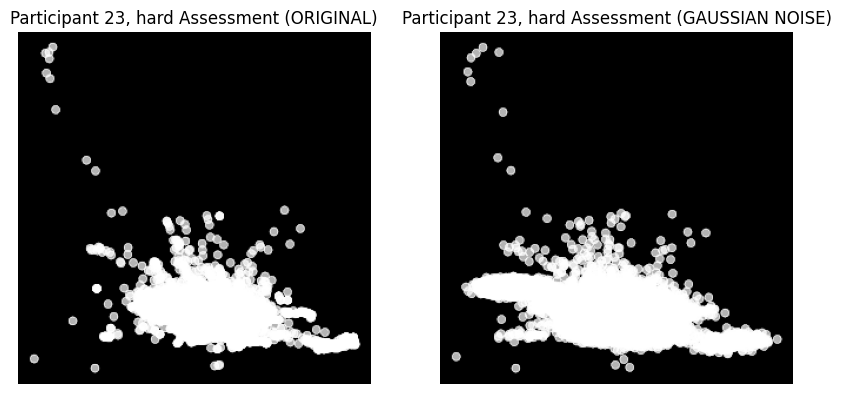

In [ ]:
participant_id, diff = random.sample(pid_assessment_train_pair, 1)[0]

# Define the image paths
img1_path = os.path.join(FPOG_SCANPATHS_PATH, f"Participant {participant_id}", f"FPOG {diff}.png")
img2_path = os.path.join(DATA_AUGMENTATION_PATH, 'Images', f"participant{participant_id}_{diff}_assessment.png")  # Change this to the second image

# Read images in grayscale
img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

# Define a uniform resize size
img_size = (300, 300)  # Modify as needed
img1 = cv2.resize(img1, img_size)
img2 = cv2.resize(img2, img_size)

# Display images side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Show first image
axes[0].imshow(img1, cmap='gray')
axes[0].set_title(f"Participant {participant_id}, {diff} Assessment (ORIGINAL)")
axes[0].axis('off')  # Hide axes

# Show second image
axes[1].imshow(img2, cmap='gray')
axes[1].set_title(f"Participant {participant_id}, {diff} Assessment (GAUSSIAN NOISE)")
axes[1].axis('off')  # Hide axes

# Show the figure
plt.show()


## Adding duplicate columns for `X_categorical_actual_train` and adding duplicate labels for `y_train`

In [ ]:
X_categorical_synthetic_train = X_categorical_actual_train.copy()
y_synthetic_train = y_actual_train.copy()

In [ ]:
# Dropping irrelevant columns from categorical data
X_categorical_actual_train.drop(columns=['Group', 'Participant ID'], inplace=True)
X_categorical_actual_train.reset_index(drop=True, inplace=True)

X_categorical_synthetic_train.drop(columns=['Group', 'Participant ID'], inplace=True)
X_categorical_synthetic_train.reset_index(drop=True, inplace=True)

X_categorical_test.drop(columns=['Group', 'Participant ID'], inplace=True)
X_categorical_test.reset_index(drop=True, inplace=True)

X_categorical_actual_train.shape, X_categorical_synthetic_train.shape, X_categorical_test.shape

((25, 13), (25, 13), (17, 13))

## Combining actual training and synthetic training datasets together into one training set

In [ ]:
# Combining tall timeseries training
X_timeseries_train = X_timeseries_actual_train + X_timeseries_synthetic_train
len(X_timeseries_train)

50

In [ ]:
# Combining all categorical training
X_categorical_train = pd.concat([X_categorical_actual_train, X_categorical_synthetic_train], axis=0)
X_categorical_train.reset_index(drop=True, inplace=True)
len(X_categorical_train)

50

In [ ]:
# Combining all image training
a, b = np.array(X_image_actual_train), np.array(X_image_synthetic_train)
X_image_train = np.concatenate((a, b), axis=0)
X_image_train.shape

(50, 70, 70)

In [ ]:
# Combining all y train (labels)
y_train = list(y_actual_train) + list(y_synthetic_train)
y_train = np.array(y_train)
len(y_train)

50

In [ ]:
print(f"Number of testing datapoints: X_test (timeseries, categorical): {len(X_timeseries_test), len(X_categorical_test), len(X_image_test)}, y_test: {len(y_test)}")

Number of testing datapoints: X_test (timeseries, categorical): (17, 17, 17), y_test: 17


# Data Preprocessing ⚙
---

## Preprocess timeseries data

In [ ]:
# Normalize each participant's DataFrame individually.
def scale_timeseries_data(X):
    X_scaled = []

    for df in X:
        scaler = MinMaxScaler()
        scaled_values = scaler.fit_transform(df.values)
        # Create a new DataFrame to hold the scaled values
        scaled_df = pd.DataFrame(scaled_values, columns=df.columns)
        X_scaled.append(scaled_df)

    return X_scaled

In [ ]:
X_timeseries_train = scale_timeseries_data(X_timeseries_train)
X_timeseries_test = scale_timeseries_data(X_timeseries_test)

All time series are different lengths. We must use padding to have them the same lengths

In [ ]:
max_seq_length = 0

for sequence in X_timeseries_train + X_timeseries_test:
    max_seq_length = max(max_seq_length, len(sequence))

print(f"Padding with max sequence length: {max_seq_length}")


# Pad sequences to the max length (Expected: 248)
X_timeseries_train = pad_sequences(X_timeseries_train, maxlen=max_seq_length, padding='post', dtype='float32')
X_timeseries_test = pad_sequences(X_timeseries_test, maxlen=max_seq_length, padding='post', dtype='float32')

Padding with max sequence length: 248


## Preprocess categorical data

In [ ]:
X_categorical_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Mental Demand          50 non-null     int64  
 1   Physical Demand        50 non-null     int64  
 2   Temporal Demand        50 non-null     int64  
 3   Performance            50 non-null     int64  
 4   Effort                 50 non-null     int64  
 5   Frustration            50 non-null     int64  
 6   Hours Awake            50 non-null     float64
 7   Pre-Sleepiness Scale   50 non-null     int64  
 8   Post-Sleepiness Scale  50 non-null     int64  
 9   Assessment             50 non-null     object 
 10  Elapsed Minutes        50 non-null     float64
 11  Python Experience      50 non-null     object 
 12  Year of Study          50 non-null     object 
dtypes: float64(2), int64(8), object(3)
memory usage: 5.2+ KB


One Hot Encoding of Nominal variables: `Group` and `Year of Study`

In [ ]:
# We can change the `Year of Study` feature to divide between undergrad and graduate students strictly.
X_categorical_train['Year of Study'] = X_categorical_train['Year of Study'].apply(lambda x: 'Undergrad' if 'Undergrad' in x else 'Grad')
X_categorical_test['Year of Study'] = X_categorical_test['Year of Study'].apply(lambda x: 'Undergrad' if 'Undergrad' in x else 'Grad')

In [ ]:
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')  # `drop=first` to prevent multicollinearity

# Fit and transform the data
train_encoded = encoder.fit_transform(X_categorical_train[['Year of Study', 'Assessment']])
test_encoded = encoder.transform(X_categorical_test[['Year of Study', 'Assessment']])

# Convert to DataFrame with column names
train_encoded_df = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(['Year of Study', 'Assessment']))
test_encoded_df = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(['Year of Study', 'Assessment']))

# Drop original categorical columns and concatenate with encoded features
X_categorical_train = pd.concat([X_categorical_train.drop(columns=['Year of Study', 'Assessment']), train_encoded_df], axis=1)
X_categorical_test = pd.concat([X_categorical_test.drop(columns=['Year of Study', 'Assessment']), test_encoded_df], axis=1)

Scaling numerical columns:
`Mental Demand`,
`Physical Demand`,
`Temporal Demand`,
`Performance`,
`Effort`,
`Frustration`,
`Hours Awake`,
`Elapsed Minutes`,
`Pre-Sleepiness Scale`,
`Post-Sleepiness Scale`

In [ ]:
scaler = MinMaxScaler()
numerical_columns = [
    'Mental Demand',
    'Physical Demand',
    'Temporal Demand',
    'Performance',
    'Effort',
    'Frustration',
    'Hours Awake',
    'Elapsed Minutes',
    'Pre-Sleepiness Scale',
    'Post-Sleepiness Scale'
]

X_categorical_train[numerical_columns] = scaler.fit_transform(X_categorical_train[numerical_columns])
X_categorical_test[numerical_columns] = scaler.transform(X_categorical_test[numerical_columns])

Ordinal Encoding of Ordinal variables: `Python Experience`

In [ ]:
experience_level = list(X_categorical_train['Python Experience'].unique())
experience_level

['Less than 1 year', '1 - 2 years', '2 year or more']

In [ ]:
encoder = OrdinalEncoder(categories=[experience_level])

X_categorical_train[['Python Experience']] = encoder.fit_transform(X_categorical_train[['Python Experience']])
X_categorical_test[['Python Experience']] = encoder.transform(X_categorical_test[['Python Experience']])

In [ ]:
X_categorical_train.head()

,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration,Hours Awake,Pre-Sleepiness Scale,Post-Sleepiness Scale,Elapsed Minutes,Python Experience,Year of Study_Undergrad,Assessment_hard
0,0.666667,0.25,0.6,0.50,0.25,0.2,0.428571,1.000000,0.666667,0.000000,0.0,1.0,0.0
1,0.666667,0.25,0.4,0.75,0.25,0.2,0.238095,0.500000,0.333333,0.135387,0.0,1.0,0.0
2,0.000000,0.25,0.6,1.00,0.00,0.0,0.238095,0.333333,0.500000,0.141778,0.0,1.0,0.0
3,0.000000,1.00,0.2,0.75,0.50,0.2,0.428571,0.333333,0.833333,0.068566,1.0,1.0,0.0
4,0.666667,0.25,0.2,0.75,1.00,0.0,0.238095,0.000000,0.166667,0.156574,0.0,1.0,0.0


## Preprocess Image Data

Rearranging the shape of train and test datasets to have one more dimension at the end representing color channels:

(Number of Images x Height x Width x Color Channels)

In [ ]:
X_image_train.shape, X_image_test.shape

((50, 70, 70), (17, 70, 70))

In [ ]:
X_image_train = np.expand_dims(X_image_train, axis=-1)
X_image_test = np.expand_dims(X_image_test, axis=-1)

X_image_train.shape, X_image_test.shape

((50, 70, 70, 1), (17, 70, 70, 1))

# Model Training 🤖

---

Helper functions

In [ ]:
def plot_history(history):
    # Create a figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

    # Plot Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].legend()

    # Plot Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Model Loss')
    axes[1].legend()

    # Show the plots
    plt.tight_layout()
    plt.show()

def evaluate_test_predictions(model, X_input):
    # ---------- Get best test accuracy ----------
    test_loss, test_acc = model.evaluate(X_input, y_test)
    print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

    # ---------- Evaluate indiviudal predictions ----------
    predictions = (model.predict(X_input) > 0.5).astype(int)
    print(classification_report(y_test, predictions))

    # Compute the confusion matrix
    cm = confusion_matrix(y_test, predictions)

    # Plot the confusion matrix using Seaborn
    plt.figure(figsize=(4, 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')

In [ ]:
saved_models = os.path.join(CECS_698_PATH, 'Saved Models')
if not os.path.exists(saved_models):
    os.makedirs(saved_models)
    print(f"Created {saved_models}")
else:
    print(f"{saved_models} already exists")

model_history = os.path.join(saved_models, 'Model History')
if not os.path.exists(model_history):
    os.makedirs(model_history)
    print(f"Created {model_history}")
else:
    print(f"{model_history} already exists")

Created /content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models
Created /content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models/Model History


## Single Modal: Timeseries

In [ ]:
num_features = X_timeseries_train.shape[2]

model = Sequential()
# model.add(Masking(mask_value=0., input_shape=(None, num_features)))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Output for binary classification

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
filename = 'one-modal-data-augmentation'
one_modal_path = os.path.join(saved_models, f"{filename}.h5")
one_modal_history = os.path.join(model_history, f"{filename}.pkl")

# If this model exists, don't do any more traing
if os.path.exists(one_modal_path) and os.path.exists(one_modal_history):
    print(f"Model already exists")
else:
    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
    checkpoint_callback = ModelCheckpoint(
        filepath=one_modal_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    # Train the Model
    history = model.fit(X_timeseries_train, y_train, epochs=500, batch_size=8, callbacks=[early_stop, checkpoint_callback], validation_data=(X_timeseries_test, y_test))

    # Save history
    with open(one_modal_history, 'wb') as f:
        pickle.dump(history, f)

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.4565 - loss: 0.6926
Epoch 1: val_accuracy improved from -inf to 0.52941, saving model to /content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models/one-modal-data-augmentation.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 298ms/step - accuracy: 0.4569 - loss: 0.6926 - val_accuracy: 0.5294 - val_loss: 0.6816
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.4901 - loss: 0.6895
Epoch 2: val_accuracy did not improve from 0.52941
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step - accuracy: 0.4938 - loss: 0.6890 - val_accuracy: 0.5294 - val_loss: 0.6763
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.4737 - loss: 0.6883
Epoch 3: val_accuracy did not improve from 0.52941
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 0.4795 - loss: 0.6872 - val_accuracy: 0.5294 - val_loss: 0.6717
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5442 - loss: 0.6781
Epoch 4: val_accuracy did not improve from 0.52941
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.5412 - loss: 0.6783 - val_accuracy: 0.5294 - val_loss: 0.6666
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5265 - loss: 0.6638
Epoch 5: val_accuracy did not improve from 0.52

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.6029 - loss: 0.6460 - val_accuracy: 0.7059 - val_loss: 0.6280
Epoch 11/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7116 - loss: 0.5993
Epoch 11: val_accuracy did not improve from 0.70588
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.7102 - loss: 0.6004 - val_accuracy: 0.7059 - val_loss: 0.5994
Epoch 12/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7702 - loss: 0.5176
Epoch 12: val_accuracy did not improve from 0.70588
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - accuracy: 0.7740 - loss: 0.5140 - val_accuracy: 0.2353 - val_loss: 1.0833
Epoch 13/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7217 - loss: 0.4999
Epoch 13: val_accuracy did not improve from 0.70588
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.7190 - loss: 0.5072 - val_accuracy: 0.4706 - val_loss: 1.0034
Epoch 14/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.4351 - loss: 0.9099
Epoch 14: val_accuracy did not improve f

In [ ]:
# Load model (With best parameters for maximal accuracy)
model = load_model(one_modal_path)

# Load model history
with open(one_modal_history, 'rb') as f:
    history = pickle.load(f)

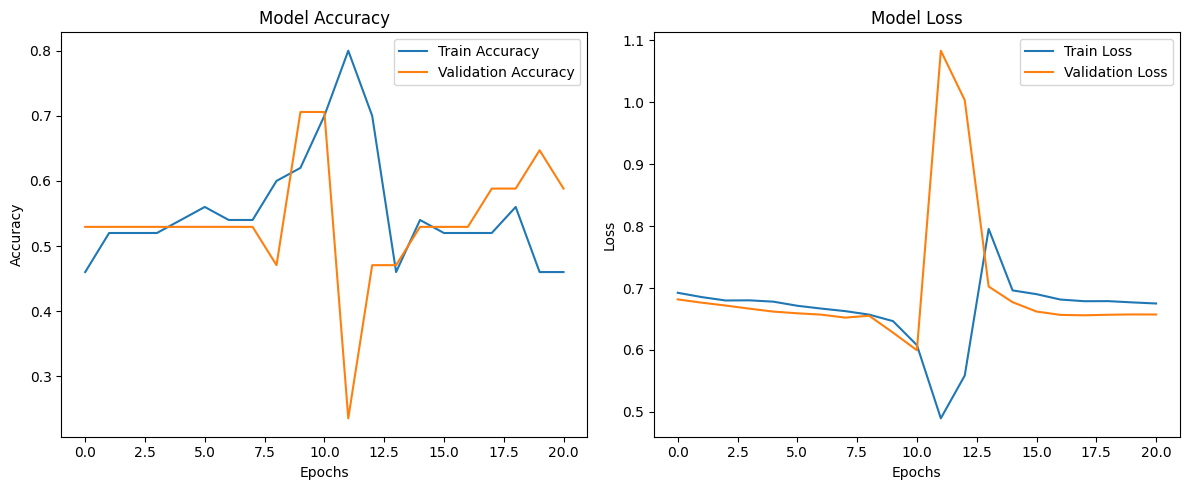

In [ ]:
plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7059 - loss: 0.6280
Test Accuracy: 0.7059, Test Loss: 0.6280
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
              precision    recall  f1-score   support

           0       0.64      0.88      0.74         8
           1       0.83      0.56      0.67         9

    accuracy                           0.71        17
   macro avg       0.73      0.72      0.70        17
weighted avg       0.74      0.71      0.70        17



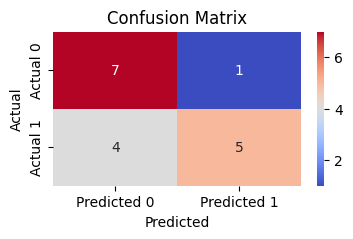

In [ ]:
evaluate_test_predictions(model, [X_timeseries_test])

## Introducing multi-modal: Timeseries + Questionnaires

In [ ]:
# Time Series Input (LSTM)
num_timeseries_features = X_timeseries_train.shape[2]
time_input = Input(shape=(None, num_timeseries_features), name="Time_Series_Input")
ts = LSTM(64, return_sequences=True)(time_input)
ts = Dropout(0.2)(ts)
ts = LSTM(32, return_sequences=False)(ts)
ts = Dropout(0.2)(ts)
ts = Dense(16, activation='relu')(ts)

## Questionnaire Input (Dense)
num_questionnaire_features = X_categorical_train.shape[1]
questionnaire_input = Input(shape=(num_questionnaire_features,), name='Questionnaire_Input')
q = Dense(64, activation='relu')(questionnaire_input)
q = Dropout(0.2)(q)
q = Dense(32, activation='relu')(q)
q = Dropout(0.2)(q)
q = Dense(16, activation='relu')(q)

## Merge all inputs
merged = Concatenate()([ts, q])
output = Dense(1, activation='sigmoid', name="Output")(merged)

# Define model
model = Model(inputs=[time_input, questionnaire_input], outputs=output)

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Time_Series_Input         │ (None, None, 64)       │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Questionnaire_Input       │ (None, 13)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_2 (LSTM)             │ (None, None, 64)       │         33,024 │ Time_Series_Input[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 64)             │            896 │ Questionnaire_Input[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, None, 64)       │              0 │ lstm_2[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 64)             │              0 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_3 (LSTM)             │ (None, 32)             │         12,416 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 32)             │          2,080 │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 32)             │              0 │ lstm_3[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 32)             │              0 │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 16)             │            528 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 16)             │            528 │ dropout_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 32)             │              0 │ dense_2[0][0],         │
│                           │                        │                │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Output (Dense)            │ (None, 1)              │             33 │ concatenate[0][0]      │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 49,505 (193.38 KB)

 Trainable params: 49,505 (193.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
filename = 'two-modal-data-augmentation'
two_modal_path = os.path.join(saved_models, f"{filename}.h5")
two_modal_history = os.path.join(model_history, f"{filename}.pkl")

# If this model exists, don't do any more traing
if os.path.exists(two_modal_path) and os.path.exists(two_modal_history):
    print(f"Model already exists")
else:
    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
    checkpoint_callback = ModelCheckpoint(
        filepath=two_modal_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    # Train the Model
    history = model.fit(
        [X_timeseries_train, X_categorical_train], y_train,
        epochs=500,
        batch_size=8,
        validation_data=([X_timeseries_test, X_categorical_test], y_test),
        callbacks=[early_stop, checkpoint_callback]
    )

    # Save history
    with open(two_modal_history, 'wb') as f:
        pickle.dump(history, f)

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5740 - loss: 0.6546
Epoch 1: val_accuracy improved from -inf to 0.52941, saving model to /content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models/two-modal-data-augmentation.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step - accuracy: 0.5672 - loss: 0.6565 - val_accuracy: 0.5294 - val_loss: 0.7052
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.4711 - loss: 0.6861
Epoch 2: val_accuracy did not improve from 0.52941
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.4747 - loss: 0.6847 - val_accuracy: 0.5294 - val_loss: 0.7016
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.4973 - loss: 0.6873
Epoch 3: val_accuracy did not improve from 0.52941
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 349ms/step - accuracy: 0.5051 - loss: 0.6849 - val_accuracy: 0.5294 - val_loss: 0.6925
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5357 - loss: 0.6894
Epoch 4: val_accuracy did not improve from 0.52941
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.5387 - loss: 0.6867 - val_accuracy: 0.5294 - val_loss: 0.6841
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6148 - loss: 0.6644
Epoch 5: val_accuracy did not improve from 0.52

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step - accuracy: 0.7799 - loss: 0.5310 - val_accuracy: 0.5882 - val_loss: 0.6147
Epoch 13/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8955 - loss: 0.4984
Epoch 13: val_accuracy did not improve from 0.58824
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.8961 - loss: 0.4992 - val_accuracy: 0.5294 - val_loss: 0.6298
Epoch 14/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9420 - loss: 0.4609
Epoch 14: val_accuracy did not improve from 0.58824
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - accuracy: 0.9418 - loss: 0.4604 - val_accuracy: 0.5294 - val_loss: 0.6214
Epoch 15/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9303 - loss: 0.4253
Epoch 15: val_accuracy did not improve from 0.58824
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.9215 - loss: 0.4301 - val_accuracy: 0.5294 - val_loss: 0.6187
Epoch 16/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7331 - loss: 0.5007
Epoch 16: val_accuracy did not improve f

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.8115 - loss: 0.4184 - val_accuracy: 0.6471 - val_loss: 0.6014
Epoch 21/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8929 - loss: 0.3414
Epoch 21: val_accuracy did not improve from 0.64706
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.8988 - loss: 0.3385 - val_accuracy: 0.6471 - val_loss: 0.6143
Epoch 22/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9125 - loss: 0.3120
Epoch 22: val_accuracy did not improve from 0.64706
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - accuracy: 0.9109 - loss: 0.3113 - val_accuracy: 0.6471 - val_loss: 0.6133
Epoch 23/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7586 - loss: 0.3767
Epoch 23: val_accuracy did not improve from 0.64706
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - accuracy: 0.7638 - loss: 0.3727 - val_accuracy: 0.4706 - val_loss: 0.6553
Epoch 24/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9709 - loss: 0.2266
Epoch 24: val_accuracy did not improve f

In [ ]:
# Load model (With best parameters for maximal accuracy)
model = load_model(two_modal_path)

# Load model history
with open(two_modal_history, 'rb') as f:
    history = pickle.load(f)

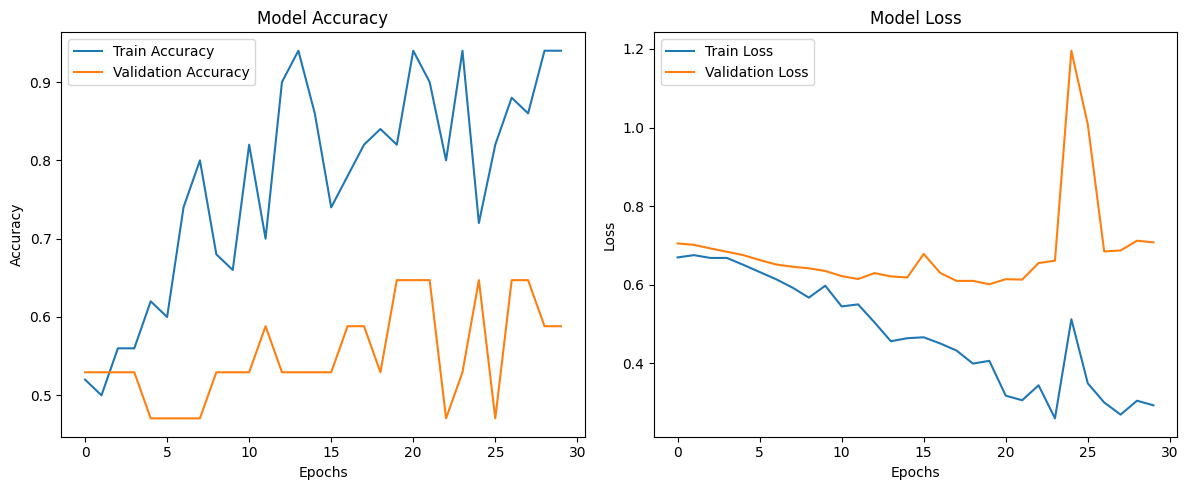

In [ ]:
plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6471 - loss: 0.6014
Test Accuracy: 0.6471, Test Loss: 0.6014
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step
              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.67      0.67      0.67         9

    accuracy                           0.65        17
   macro avg       0.65      0.65      0.65        17
weighted avg       0.65      0.65      0.65        17



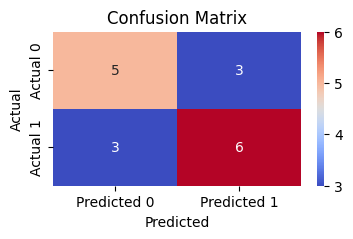

In [ ]:
evaluate_test_predictions(model, [X_timeseries_test, X_categorical_test])

## Adding one more modal: Timeseries + Questionnaires + Images

In [ ]:
# Time Series Input (LSTM)
num_timeseries_features = X_timeseries_train.shape[2]
time_input = Input(shape=(None, num_timeseries_features), name="Time_Series_Input")
ts = LSTM(64, return_sequences=True)(time_input)
ts = Dropout(0.2)(ts)
ts = LSTM(32, return_sequences=False)(ts)
ts = Dropout(0.2)(ts)
ts = Dense(16, activation='relu')(ts)

## Questionnaire Input (Dense)
num_questionnaire_features = X_categorical_train.shape[1]
questionnaire_input = Input(shape=(num_questionnaire_features,), name='Questionnaire_Input')
q = Dense(64, activation='relu')(questionnaire_input)
q = Dropout(0.2)(q)
q = Dense(32, activation='relu')(q)
q = Dropout(0.2)(q)
q = Dense(16, activation='relu')(q)

# Image Input (CNN)
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 1)
image_input = Input(shape=input_shape, name="Image_Input")
img = Conv2D(64, (3, 3), activation='relu')(image_input)
img = MaxPooling2D((2, 2))(img)
img = Conv2D(32, (3, 3), activation='relu')(img)
img = MaxPooling2D((2, 2))(img)
img = Conv2D(16, (3, 3), activation='relu')(img)
img = MaxPooling2D((2, 2))(img)
img = Flatten()(img)
img = Dense(64, activation='relu')(img)

## Merge all inputs
merged = Concatenate()([ts, q, img])
output = Dense(1, activation='sigmoid', name="Output")(merged)

# Define model
model = Model(inputs=[time_input, questionnaire_input, image_input], outputs=output)

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Image_Input (InputLayer)  │ (None, 70, 70, 1)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 68, 68, 64)     │            640 │ Image_Input[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 34, 34, 64)     │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Time_Series_Input         │ (None, None, 64)       │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Questionnaire_Input       │ (None, 13)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 32, 32, 32)     │         18,464 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_4 (LSTM)             │ (None, None, 64)       │         33,024 │ Time_Series_Input[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 64)             │            896 │ Questionnaire_Input[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 16, 16, 32)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, None, 64)       │              0 │ lstm_4[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_8 (Dropout)       │ (None, 64)             │              0 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 14, 14, 16)     │          4,624 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_5 (LSTM)             │ (None, 32)             │         12,416 │ dropout_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 32)             │          2,080 │ dropout_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 7, 7, 16)       │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_7 (Dropout)       │ (None, 32)             │              0 │ lstm_5[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_9 (Dropout)       │ (None, 32)             │              0 │ dense_8[0][0]          │
├──────────────────────

 Total params: 123,537 (482.57 KB)

 Trainable params: 123,537 (482.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# # Visualize model structure
# plot_model(
#     model,
#     show_shapes=True,  # Display input/output shapes
#     show_layer_names=True,  # Display layer names
#     expand_nested=True,  # Expand nested models if any
#     dpi=60  # Adjust resolution
# )

In [ ]:
filename = 'three-modal-data-augmentation'
three_modal_path = os.path.join(saved_models, f"{filename}.h5")
three_modal_history = os.path.join(model_history, f"{filename}.pkl")

# If this model exists, don't do any more traing
if os.path.exists(three_modal_path) and os.path.exists(three_modal_history):
    print(f"Model already exists")
else:
    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
    checkpoint_callback = ModelCheckpoint(
        filepath=three_modal_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    # Train the Model
    history = model.fit(
        [X_timeseries_train, X_categorical_train, X_image_train], y_train,
        epochs=500,
        batch_size=8,
        validation_data=([X_timeseries_test, X_categorical_test, X_image_test], y_test),
        callbacks=[early_stop, checkpoint_callback]
    )

    # Save history
    with open(three_modal_history, 'wb') as f:
        pickle.dump(history, f)

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.3958 - loss: 0.7099
Epoch 1: val_accuracy improved from -inf to 0.58824, saving model to /content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models/three-modal-data-augmentation.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 447ms/step - accuracy: 0.4038 - loss: 0.7084 - val_accuracy: 0.5882 - val_loss: 0.6841
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.5343 - loss: 0.6432
Epoch 2: val_accuracy did not improve from 0.58824
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 268ms/step - accuracy: 0.5350 - loss: 0.6426 - val_accuracy: 0.5882 - val_loss: 0.6801
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.6463 - loss: 0.5815
Epoch 3: val_accuracy improved from 0.58824 to 0.64706, saving model to /content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models/three-modal-data-augmentation.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - accuracy: 0.6555 - loss: 0.5796 - val_accuracy: 0.6471 - val_loss: 0.6527
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9098 - loss: 0.4607
Epoch 4: val_accuracy did not improve from 0.64706
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.9035 - loss: 0.4617 - val_accuracy: 0.5882 - val_loss: 0.6924
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8510 - loss: 0.4375
Epoch 5: val_accuracy did not improve from 0.64706
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step - accuracy: 0.8496 - loss: 0.4342 - val_accuracy: 0.6471 - val_loss: 0.6446
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9420 - loss: 0.2495
Epoch 6: val_accuracy did not improve from 0.64706
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 323ms/step - accuracy: 0.9418 - loss: 0.2478 - val_accuracy: 0.5882 - val_loss: 0.7178
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 1.0000 - loss: 0.1181
Epoch 7: val_accuracy did not improve from 0.64

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 296ms/step - accuracy: 0.9802 - loss: 0.0586 - val_accuracy: 0.7647 - val_loss: 0.8791
Epoch 9/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 1.0000 - loss: 0.0143
Epoch 9: val_accuracy did not improve from 0.76471
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 1.0000 - loss: 0.0145 - val_accuracy: 0.5882 - val_loss: 1.0329
Epoch 10/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 1.0000 - loss: 0.0059
Epoch 10: val_accuracy did not improve from 0.76471
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.6471 - val_loss: 1.0274
Epoch 11/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 1.0000 - loss: 0.0025
Epoch 11: val_accuracy did not improve from 0.76471
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.6471 - val_loss: 1.0904
Epoch 12/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 12: val_accuracy did not improve fro

In [ ]:
# Load model (With best parameters for maximal accuracy)
model = load_model(three_modal_path)

# Load model history
with open(three_modal_history, 'rb') as f:
    history = pickle.load(f)

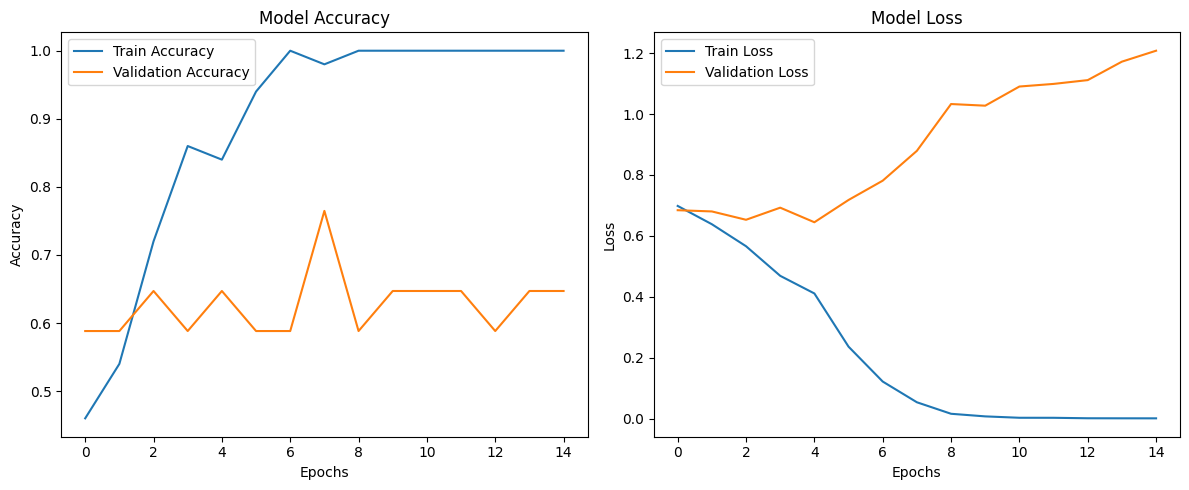

In [ ]:
plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7647 - loss: 0.8791
Test Accuracy: 0.7647, Test Loss: 0.8791
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.86      0.67      0.75         9

    accuracy                           0.76        17
   macro avg       0.78      0.77      0.76        17
weighted avg       0.78      0.76      0.76        17



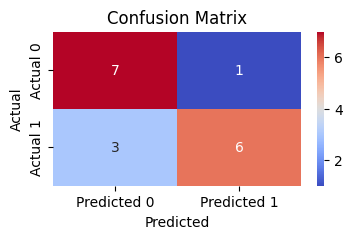

In [ ]:
evaluate_test_predictions(model, [X_timeseries_test, X_categorical_test, X_image_test])

In [ ]:
X_categorical_train

,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration,Hours Awake,Pre-Sleepiness Scale,Post-Sleepiness Scale,Elapsed Minutes,Python Experience,Year of Study_Undergrad,Assessment_hard
0,0.666667,0.25,0.6,0.50,0.25,0.2,0.428571,1.000000,0.666667,0.000000,0.0,1.0,0.0
1,0.666667,0.25,0.4,0.75,0.25,0.2,0.238095,0.500000,0.333333,0.135387,0.0,1.0,0.0
2,0.000000,0.25,0.6,1.00,0.00,0.0,0.238095,0.333333,0.500000,0.141778,0.0,1.0,0.0
3,0.000000,1.00,0.2,0.75,0.50,0.2,0.428571,0.333333,0.833333,0.068566,1.0,1.0,0.0
4,0.666667,0.25,0.2,0.75,1.00,0.0,0.238095,0.000000,0.166667,0.156574,0.0,1.0,0.0
5,1.000000,0.00,0.2,0.25,0.75,1.0,0.047619,0.666667,0.833333,0.778620,2.0,0.0,1.0
6,0.333333,0.50,0.4,0.25,0.25,0.2,0.904762,0.500000,0.333333,0.750729,2.0,0.0,1.0
7,0.333333,0.50,0.4,0.25,0.25,0.2,0.619048,0.666667,1.000000,0.040090,0.0,1.0,0.0
8,0.666667,0.00,0.6,0.50,0.50,0.4,0.000000,0.500000,0.333333,0.057523,1.0,1.0,0.0
9,0.666667,0.00,0.6,0.50,0.50,0.4,0.000000,0.500000,0.333333,0.355025,1.0,1.0,1.0
